In [17]:
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [18]:
# Adjust this path to your dataset location
csv_path = r'C:/Users/Vido/Desktop/EPL448/accepted_2007_to_2018q4.csv/accepted_2007_to_2018q4.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f'CSV file not found at {csv_path}')

# Use a smaller sample for rapid iteration, or set sample_n=None for full data
sample_n = None
df = pd.read_csv(csv_path, low_memory=False, nrows=sample_n)
print('Loaded rows:', len(df))

Loaded rows: 2260701


In [19]:
# Keep binary target only
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Reduce to core features for emp_length clustering plus strong predictors
features = ['loan_amnt','term','int_rate','dti','annual_inc','open_acc','total_acc','revol_bal','revol_util','grade','sub_grade','home_ownership','verification_status','emp_length']
available = [c for c in features if c in df.columns]
print('Using columns', available)
df = df[available + ['target']]

Using columns ['loan_amnt', 'term', 'int_rate', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'emp_length']


In [20]:
# Inspect raw emp_length distribution before preprocessing
print('emp_length unique count:', df['emp_length'].nunique(dropna=False))
print('emp_length value counts')
print(df['emp_length'].value_counts(dropna=False))

# Normalize and keep emp_length categories
def normalize_emp_length(e):
    #Find Unknowns-Empty values
    if pd.isna(e):
        return 'Unknown'
    s = str(e).strip()
    if s in ['n/a', 'Unknown', '']:
        return 'Unknown'

    # Flatten common suffixes and whitespace
    s = s.replace(' years', '').replace(' year', '').strip()

    # Convert edge cases
    if s.startswith('<'):
        # "< 1" or "<1" -> 0
        return '0'
    if s.endswith('+'):
        # "10+" -> 10
        s = s[:-1]

    # remove any leftover '+' or non-digit text
    s = s.strip().replace('+', '').strip()

    try:
        v = int(s)
        return str(v)
    except Exception:
        return 'Unknown'

df['emp_length_norm'] = df['emp_length'].apply(normalize_emp_length)
df['emp_length_is_unknown'] = (df['emp_length_norm'] == 'Unknown').astype(int)

# Derive categories dynamically and sort them
vals = [int(x) for x in df['emp_length_norm'] if x != 'Unknown' and x.isdigit()]
vals = sorted(set(vals))
unique_emp_length = [str(x) for x in vals] + ['Unknown']
print('cached emp_length categories:', unique_emp_length)

# Create numeric version of emp_length for inspection or optional modeling,
# with 'Unknown' as the last category.
code_map = {v: i for i, v in enumerate(unique_emp_length)}
df['emp_length_code'] = df['emp_length_norm'].map(code_map).fillna(len(unique_emp_length) - 1).astype(int)


emp_length unique count: 12
emp_length value counts
emp_length
10+ years    442199
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
NaN           78511
6 years       62733
8 years       60701
7 years       59624
9 years       50937
Name: count, dtype: int64
cached emp_length categories: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'Unknown']


Filled missing dti with median: 17.61
Rows with imputed dti: 374
Elbow summary:
    k  avg_distance_to_centroid
0   1                  2.253376
1   2                  1.992810
2   3                  1.867291
3   4                  1.862222
4   5                  1.743463
5   6                  1.710023
6   7                  1.639927
7   8                  1.637467
8   9                  1.586474
9  10                  1.551246
Elbow sample size: 50000


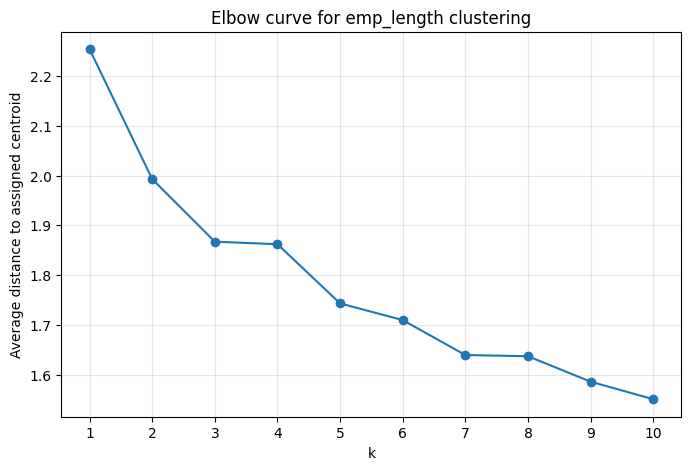

In [21]:
# Cluster using borrower features only.
# Exclude emp_length-derived columns so unknown rows are not biased by code 11.
# Fill missing dti so rows with incomplete debt-to-income data can still receive a cluster.
dti_median = df['dti'].median()
df['dti_filled'] = df['dti'].fillna(dti_median)
print('Filled missing dti with median:', dti_median)
print('Rows with imputed dti:', int(df['dti'].isna().sum()))

cluster_features = ['loan_amnt', 'dti_filled', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'revol_util_num']

known_df = df[df['emp_length_is_unknown'] == 0].copy()
known_df['emp_length_num'] = known_df['emp_length_norm'].astype(int)
known_df['revol_util_num'] = pd.to_numeric(
    known_df['revol_util'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
).fillna(0)
known_df = known_df.dropna(subset=cluster_features)
#Normalize features for clustering
X = known_df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try a range of k values and look at the average distance to the assigned centroid.
# Use a reproducible sample so the elbow check stays manageable on the full dataset.
elbow_k_values = list(range(1, 11))
elbow_sample_size = min(50000, len(X_scaled))
if len(X_scaled) > elbow_sample_size:
    elbow_indices = np.random.RandomState(42).choice(len(X_scaled), size=elbow_sample_size, replace=False)
    X_elbow_scaled = X_scaled[elbow_indices]
else:
    X_elbow_scaled = X_scaled

avg_distance_to_centroid = []
for k in elbow_k_values:
    elbow_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    elbow_labels = elbow_kmeans.fit_predict(X_elbow_scaled)
    elbow_distances = np.linalg.norm(X_elbow_scaled - elbow_kmeans.cluster_centers_[elbow_labels], axis=1)
    avg_distance_to_centroid.append(elbow_distances.mean())

elbow_summary = pd.DataFrame({
    'k': elbow_k_values,
    'avg_distance_to_centroid': avg_distance_to_centroid
})
print('Elbow summary:')
print(elbow_summary)
print('Elbow sample size:', len(X_elbow_scaled))

plt.figure(figsize=(8, 5))
plt.plot(elbow_k_values, avg_distance_to_centroid, marker='o')
plt.xticks(elbow_k_values)
plt.xlabel('k')
plt.ylabel('Average distance to assigned centroid')
plt.title('Elbow curve for emp_length clustering')
plt.grid(True, alpha=0.3)
plt.show()




Chosen k for final model: 3


C:\Users\Vido\AppData\Local\Temp\ipykernel_6632\3927024797.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_cluster'].update(known_df['emp_cluster'])


Cluster assignment counts:
emp_cluster
0    736616
1    336907
2    271787
Name: count, dtype: int64


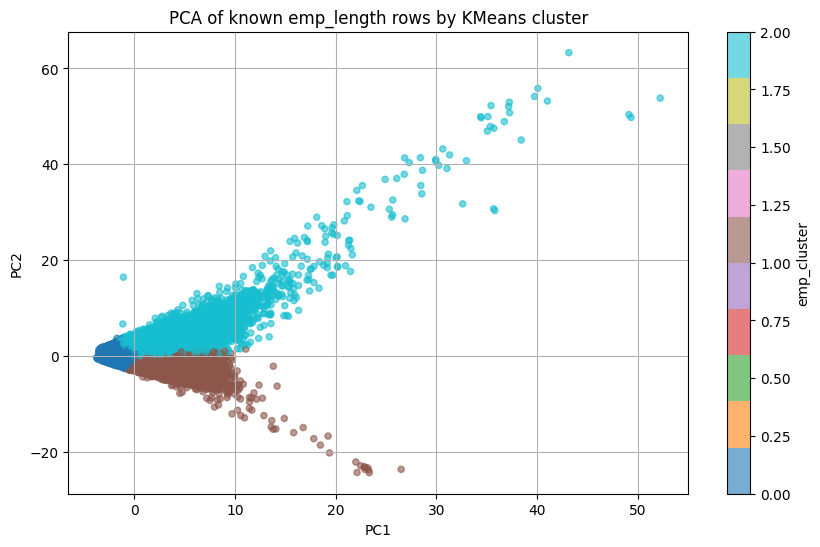

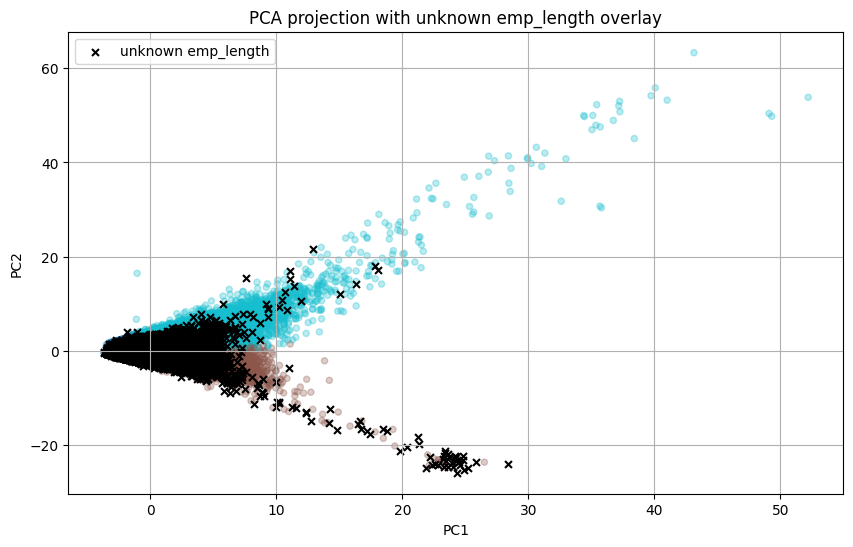

In [22]:
# Choose k after inspecting the elbow curve.
n_clusters = 3
print('Chosen k for final model:', n_clusters)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
known_df['emp_cluster'] = kmeans.fit_predict(X_scaled)

# Assign unknown rows to the nearest learned cluster in the same borrower-feature space.
unknown_df = df[df['emp_length_is_unknown'] == 1].copy()
unknown_df['revol_util_num'] = pd.to_numeric(
    unknown_df['revol_util'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
).fillna(0)
unknown_df = unknown_df.dropna(subset=cluster_features)

if not unknown_df.empty:
    X_unknown = unknown_df[cluster_features].copy()
    X_unknown_scaled = scaler.transform(X_unknown)
    distances = np.linalg.norm(X_unknown_scaled[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2)
    unknown_df['emp_cluster'] = np.argmin(distances, axis=1)
else:
    unknown_df['emp_cluster'] = pd.Series(dtype=int)

# Combine cluster labels back into the full dataframe.
df['emp_cluster'] = -1
df.loc[known_df.index, 'emp_cluster'] = known_df['emp_cluster']
if not unknown_df.empty:
    df.loc[unknown_df.index, 'emp_cluster'] = unknown_df['emp_cluster']
df['emp_cluster'] = df['emp_cluster'].astype(int)

print('Cluster assignment counts:')
print(df['emp_cluster'].value_counts())

# Plot clusters using PCA on the same borrower features used by KMeans for dimensionality reduction.
known_plot = known_df[cluster_features].copy()
known_scaled = scaler.transform(known_plot)

pca = PCA(n_components=2, random_state=42)
known_coords = pca.fit_transform(known_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(known_coords[:, 0], known_coords[:, 1], c=known_df['emp_cluster'], cmap='tab10', s=20, alpha=0.6)
plt.colorbar(label='emp_cluster')
plt.title('PCA of known emp_length rows by KMeans cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

if not unknown_df.empty:
    unknown_plot = unknown_df[cluster_features].copy()
    unknown_scaled = scaler.transform(unknown_plot)
    unknown_coords = pca.transform(unknown_scaled)

    plt.figure(figsize=(10, 6))
    plt.scatter(known_coords[:, 0], known_coords[:, 1], c=known_df['emp_cluster'], cmap='tab10', s=20, alpha=0.3)
    plt.scatter(unknown_coords[:, 0], unknown_coords[:, 1], c='k', marker='x', s=25, label='unknown emp_length')
    plt.legend()
    plt.title('PCA projection with unknown emp_length overlay')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()
else:
    print('No unknown emp_length rows with complete clustering features to project.')



In [23]:
# Summarize actual emp_length values inside each cluster and build a cluster-to-years map.
cluster_summary = known_df.groupby('emp_cluster')['emp_length_num'].agg(
    median='median',
    mean='mean',
    mode=lambda s: int(s.mode().iat[0]),
    count='count'
).sort_index()
cluster_summary['cluster_to_year'] = cluster_summary['median'].round().astype(int)
print('Cluster emp_length summary (known):')
print(cluster_summary)

cluster_to_year = cluster_summary['cluster_to_year'].to_dict()
print('Cluster to representative emp_length years:')
print(cluster_to_year)

df['emp_length_num'] = pd.to_numeric(df['emp_length_norm'], errors='coerce')
df['emp_length_cluster_estimate'] = df['emp_cluster'].map(cluster_to_year).astype('Int64')
df['emp_length_filled_from_cluster'] = df['emp_length_num']

unknown_mask = df['emp_length_is_unknown'].eq(1) & df['emp_cluster'].ne(-1)
df.loc[unknown_mask, 'emp_length_filled_from_cluster'] = df.loc[unknown_mask, 'emp_cluster'].map(cluster_to_year)
df['emp_length_filled_from_cluster'] = df['emp_length_filled_from_cluster'].astype('Int64')

print('Unknown emp_length rows filled from cluster median:')
print(int(unknown_mask.sum()))

Cluster emp_length summary (known):
             median      mean  mode   count  cluster_to_year
emp_cluster                                                 
0               5.0  5.647925    10  684547                5
1               7.0  6.176969    10  318525                7
2               8.0  6.536202    10  263727                8
Cluster to representative emp_length years:
{0: 5, 1: 7, 2: 8}
Unknown emp_length rows filled from cluster median:
78511


C:\Users\Vido\AppData\Local\Temp\ipykernel_6632\3713446414.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length_filled_from_cluster'].update(unknown_cluster_fill)
